# Notebook 07 — Enriched Bayesian Hierarchical Model

This notebook implements and evaluates the research-grade upgrades to the baseline model:

| Upgrade | Description |
|---------|-------------|
| **Full covariance** | Replace diagonal `diag(σ²)` with full Σ per component |
| **Mixture of Gaussians** | K=2 components per class |
| **Region offsets** | Region-specific feature shift (region → X interaction) |
| **Label noise** | Y_i \| Z_i ~ Bernoulli(ρ) |
| **Learned hyperpriors** | α, β updated via M-step under Gamma prior |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model_specification import default_config, load_synthetic_data
from src.exact_inference import coordinate_ascent_vi
from src.enriched_model import EnrichedConfig, enriched_fit

np.random.seed(42)
df = load_synthetic_data()
baseline_cfg = default_config()
print(f'Data: {df.shape}  |  infection rate: {df.infection_latent.mean():.3f}')

Data: (1000, 4)  |  infection rate: 0.612


## 1. Baseline CAVI (reference)

In [2]:
baseline_vi = coordinate_ascent_vi(df, baseline_cfg, max_iter=200, tol=1e-6)
baseline_acc = (baseline_vi.responsibilities.round() == df['infection_latent'].values).mean()
print(f'Baseline ELBO: {baseline_vi.elbo_history[-1]:.2f}')
print(f'Baseline accuracy: {baseline_acc:.4f}')
print(f'Baseline converged: {baseline_vi.converged} ({baseline_vi.n_iter} iter)')

Baseline ELBO: -12478.91
Baseline accuracy: 0.7760
Baseline converged: True (60 iter)


## 2. Upgrade A — Full covariance + MoG (K=1, single Gaussian with full Σ)

In [3]:
cfg_fullcov = EnrichedConfig.from_baseline(baseline_cfg, n_components=1)
res_fullcov = enriched_fit(df, cfg_fullcov, max_outer=40, tol=1e-5)

acc_fullcov = (res_fullcov.responsibilities.round() == df['infection_latent'].values).mean()
print(f'Full-cov ELBO: {res_fullcov.elbo_history[-1]:.2f}')
print(f'Full-cov accuracy: {acc_fullcov:.4f}')
print(f'Converged: {res_fullcov.converged} ({res_fullcov.n_iter} iter)')

Full-cov ELBO: -12471.21
Full-cov accuracy: 0.7610
Converged: False (40 iter)


## 3. Upgrade B — Mixture of Gaussians (K=2 per class, full Σ)

In [4]:
cfg_mog = EnrichedConfig.from_baseline(baseline_cfg, n_components=2)
res_mog = enriched_fit(df, cfg_mog, max_outer=50, tol=1e-5)

acc_mog = (res_mog.responsibilities.round() == df['infection_latent'].values).mean()
print(f'MoG (K=2) ELBO: {res_mog.elbo_history[-1]:.2f}')
print(f'MoG (K=2) accuracy: {acc_mog:.4f}')
print(f'Converged: {res_mog.converged} ({res_mog.n_iter} iter)')
print(f'\nLearned mixture weights (z=0): {res_mog.final_config.mix_weights[0].round(3)}')
print(f'Learned mixture weights (z=1): {res_mog.final_config.mix_weights[1].round(3)}')

MoG (K=2) ELBO: -12466.14
MoG (K=2) accuracy: 0.7760
Converged: False (50 iter)

Learned mixture weights (z=0): [0.506 0.494]
Learned mixture weights (z=1): [0.542 0.458]


## 4. Upgrade C — Region offsets (region → X interaction)

In [5]:
n_regions = df['region'].nunique()
cfg_offsets = EnrichedConfig.from_baseline(baseline_cfg, n_components=1, use_region_offsets=True, n_regions=n_regions)
res_offsets = enriched_fit(df, cfg_offsets, max_outer=40, tol=1e-5)

acc_offsets = (res_offsets.responsibilities.round() == df['infection_latent'].values).mean()
print(f'Region-offsets ELBO: {res_offsets.elbo_history[-1]:.2f}')
print(f'Region-offsets accuracy: {acc_offsets:.4f}')
print(f'Converged: {res_offsets.converged} ({res_offsets.n_iter} iter)')
print('\nLearned region offsets (delta_r):')
for r, delta in enumerate(res_offsets.final_config.region_offsets):
    print(f'  Region {r}: feat1={delta[0]:+.3f}  feat2={delta[1]:+.1f}')

Region-offsets ELBO: -12468.44
Region-offsets accuracy: 0.7760
Converged: False (40 iter)

Learned region offsets (delta_r):
  Region 0: feat1=-0.579  feat2=+93.1
  Region 1: feat1=+0.634  feat2=-71.7
  Region 2: feat1=+1.776  feat2=+93.4
  Region 3: feat1=+0.289  feat2=+30.9
  Region 4: feat1=-1.671  feat2=-111.1


## 5. Upgrade D — Label noise model

In [6]:
cfg_noise = EnrichedConfig.from_baseline(
    baseline_cfg, n_components=1,
    use_label_noise=True, rho_sensitivity=0.90, rho_specificity=0.90
)
res_noise = enriched_fit(df, cfg_noise, max_outer=40, tol=1e-5)

acc_noise = (res_noise.responsibilities.round() == df['infection_latent'].values).mean()
print(f'Label-noise ELBO: {res_noise.elbo_history[-1]:.2f}')
print(f'Label-noise accuracy: {acc_noise:.4f}')
print(f'Converged: {res_noise.converged} ({res_noise.n_iter} iter)')

Label-noise ELBO: -12929.63
Label-noise accuracy: 0.9880
Converged: True (8 iter)


## 6. Upgrade E — Learned hyperpriors on α, β

In [7]:
cfg_hyper = EnrichedConfig.from_baseline(baseline_cfg, n_components=1, learn_hyperpriors=True)
res_hyper = enriched_fit(df, cfg_hyper, max_outer=40, tol=1e-5)

acc_hyper = (res_hyper.responsibilities.round() == df['infection_latent'].values).mean()
print(f'Learned-hyperpriors ELBO: {res_hyper.elbo_history[-1]:.2f}')
print(f'Learned-hyperpriors accuracy: {acc_hyper:.4f}')
print(f'Converged: {res_hyper.converged} ({res_hyper.n_iter} iter)')
print(f'Learned alpha: {res_hyper.final_config.alpha_hyper:.4f}  (init: 2.0)')
print(f'Learned beta:  {res_hyper.final_config.beta_hyper:.4f}  (init: 2.0)')

Learned-hyperpriors ELBO: -12473.75
Learned-hyperpriors accuracy: 0.7630
Converged: False (40 iter)
Learned alpha: 1.6927  (init: 2.0)
Learned beta:  1.6477  (init: 2.0)


## 7. Full enriched model — all upgrades combined

In [8]:
cfg_full = EnrichedConfig.from_baseline(
    baseline_cfg,
    n_components=2,
    use_region_offsets=True,
    use_label_noise=True,
    learn_hyperpriors=True,
    rho_sensitivity=0.92,
    rho_specificity=0.92,
    n_regions=n_regions,
)
res_full = enriched_fit(df, cfg_full, max_outer=60, tol=1e-5)

acc_full = (res_full.responsibilities.round() == df['infection_latent'].values).mean()
print(f'Full-enriched ELBO: {res_full.elbo_history[-1]:.2f}')
print(f'Full-enriched accuracy: {acc_full:.4f}')
print(f'Converged: {res_full.converged} ({res_full.n_iter} iter)')
print(f'Learned alpha={res_full.final_config.alpha_hyper:.3f}  beta={res_full.final_config.beta_hyper:.3f}')

Full-enriched ELBO: -12912.91
Full-enriched accuracy: 0.9870
Converged: False (60 iter)
Learned alpha=1.582  beta=0.992


## 8. Comparison summary

In [9]:
results = [
    ('Baseline CAVI',               baseline_vi.elbo_history[-1],  baseline_acc),
    ('Full covariance (K=1)',        res_fullcov.elbo_history[-1],  acc_fullcov),
    ('MoG K=2',                      res_mog.elbo_history[-1],      acc_mog),
    ('Region offsets',               res_offsets.elbo_history[-1],  acc_offsets),
    ('Label noise (rho=0.90)',       res_noise.elbo_history[-1],    acc_noise),
    ('Learned hyperpriors',          res_hyper.elbo_history[-1],    acc_hyper),
    ('All upgrades combined',        res_full.elbo_history[-1],     acc_full),
]
print(f'{"Model":<30}  {"Final ELBO":>12}  {"Accuracy":>10}')
print('-' * 57)
for name, elbo, acc in results:
    print(f'{name:<30}  {elbo:>12.2f}  {acc:>10.4f}')

Model                             Final ELBO    Accuracy
---------------------------------------------------------
Baseline CAVI                      -12478.91      0.7760
Full covariance (K=1)              -12471.21      0.7610
MoG K=2                            -12466.14      0.7760
Region offsets                     -12468.44      0.7760
Label noise (rho=0.90)             -12929.63      0.9880
Learned hyperpriors                -12473.75      0.7630
All upgrades combined              -12912.91      0.9870


## 9. ELBO convergence plots

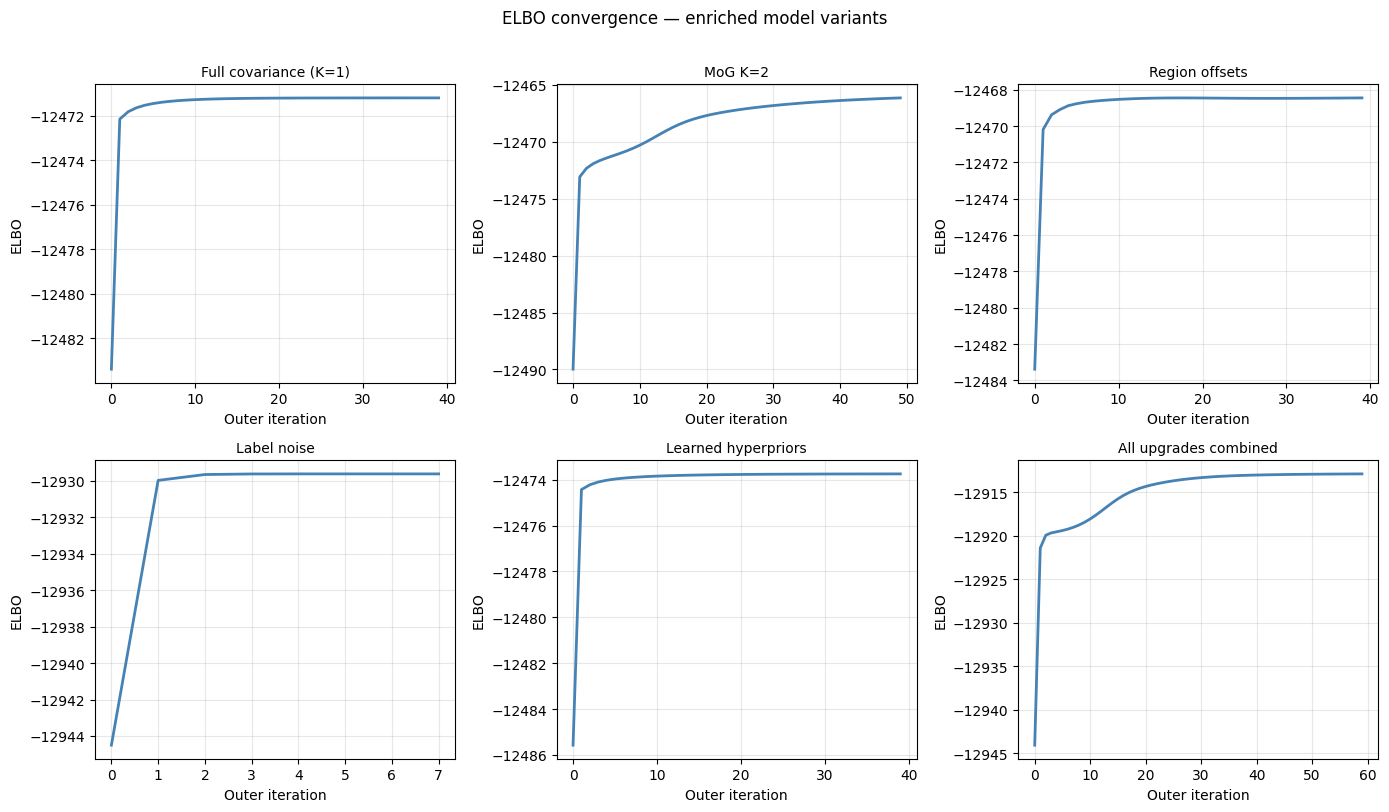

Saved to reports/enriched_elbo_convergence.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

plot_data = [
    ('Full covariance (K=1)',   res_fullcov.elbo_history),
    ('MoG K=2',                 res_mog.elbo_history),
    ('Region offsets',          res_offsets.elbo_history),
    ('Label noise',             res_noise.elbo_history),
    ('Learned hyperpriors',     res_hyper.elbo_history),
    ('All upgrades combined',   res_full.elbo_history),
]

for ax, (title, history) in zip(axes, plot_data):
    ax.plot(history, color='steelblue', linewidth=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Outer iteration')
    ax.set_ylabel('ELBO')
    ax.grid(True, alpha=0.3)

plt.suptitle('ELBO convergence — enriched model variants', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../reports/enriched_elbo_convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to reports/enriched_elbo_convergence.png')

## 10. Regional prevalence: baseline vs enriched

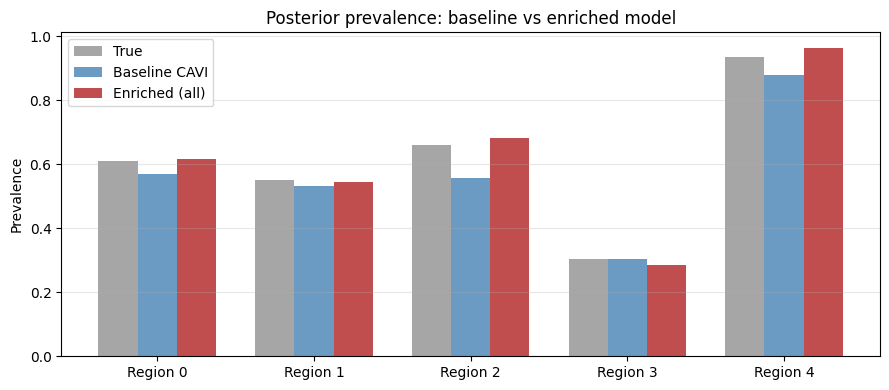

Saved to reports/enriched_prevalence_comparison.png


In [11]:
true_prev = df.groupby('region')['infection_latent'].mean()

def posterior_mean(posteriors):
    return {r: a / (a + b) for r, (a, b) in posteriors.items()}

base_means  = posterior_mean(baseline_vi.region_posteriors)
full_means  = posterior_mean(res_full.region_posteriors)

regions_sorted = sorted(base_means.keys())
x = np.arange(len(regions_sorted))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w, [true_prev[r] for r in regions_sorted],       width=w, label='True', color='gray',      alpha=0.7)
ax.bar(x,     [base_means[r] for r in regions_sorted],       width=w, label='Baseline CAVI', color='steelblue', alpha=0.8)
ax.bar(x + w, [full_means[r] for r in regions_sorted],       width=w, label='Enriched (all)', color='firebrick',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'Region {r}' for r in regions_sorted])
ax.set_ylabel('Prevalence')
ax.set_title('Posterior prevalence: baseline vs enriched model')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/enriched_prevalence_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to reports/enriched_prevalence_comparison.png')

## 11. Learned full covariance matrices

Inspect the off-diagonal correlation captured by the enriched model.

In [12]:
for z, label in enumerate(['Healthy (Z=0)', 'Infected (Z=1)']):
    for k in range(res_mog.final_config.n_components):
        cov_mat = res_mog.final_config.cov[z, k]
        stds = np.sqrt(np.diag(cov_mat))
        corr = cov_mat[0, 1] / (stds[0] * stds[1] + 1e-12)
        print(f'{label}  component {k}:')
        print(f'  sigma = [{stds[0]:.3f}, {stds[1]:.1f}]')
        print(f'  feature correlation rho = {corr:.4f}')

Healthy (Z=0)  component 0:
  sigma = [9.050, 891.2]
  feature correlation rho = -0.0635
Healthy (Z=0)  component 1:
  sigma = [12.547, 761.6]
  feature correlation rho = 0.0485
Infected (Z=1)  component 0:
  sigma = [13.229, 1002.9]
  feature correlation rho = 0.1212
Infected (Z=1)  component 1:
  sigma = [13.223, 1463.3]
  feature correlation rho = 0.0496
